# 주가예측

In [ ]:
# 주제: LSTM을 이용한 삼성전자 주가예측
# 주가데이터, FinanceDatareader
# PyTorch 와 LSTM 모델
# 회귀 문제.

# import

In [1]:
import torch
import numpy as np
import pandas as pd
from torch import nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader  # TensorDataset 은 Dataset 구현체

DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"using PyTorch version: {torch.__version__}, Device: {DEVICE}")

using PyTorch version: 2.11.0+cpu, Device: cpu


# 하이퍼 파라미터

In [2]:
FEATURE_NUMS = 4        # 입력층으로 들어가는 데이터 개수 feature
SEQ_LENGTH = 5          # 정답을 만들기 위해 필요한 시점 개수 time step
HIDDEN_SIZE = 4         # RNN 계열 계층을 구성하는 hidden state 개수
NUM_LAYERS = 1          # RNN 계열 계층이 몇겹으로 쌓였는지 나타냄
LEARNING_RATE = 1e-3    # 학습율
BATCH_SIZE = 20         # 학습을 위한 배치사이즈 개수

# Finance DataReader

In [3]:
!pip install finance-datareader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.4 MB/s eta 0:00:00


In [4]:
import FinanceDataReader as fdr

In [5]:
df = fdr.DataReader('005930', '2021-01-01', '2025-12-31')
df

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2021-01-04,81000,84400,80200,83000,38655276,0.024691
2021-01-05,81600,83900,81600,83900,35335669,0.010843
2021-01-06,83300,84500,82100,82200,42089013,-0.020262
2021-01-07,82800,84200,82700,82900,32644642,0.008516
2021-01-08,83300,90000,83000,88800,59013307,0.071170
...,...,...,...,...,...,...
2025-12-23,110900,112500,110400,111500,20419187,0.009050
2025-12-24,112400,112400,110900,111100,12492939,-0.003587
2025-12-26,112400,117000,112400,117000,34018174,0.053105


In [6]:
# 'Close' 가 타겟 값이 되고
# 입력은 'Open', 'High', 'Low', 'Volume' 로 할것이다

df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Change'], dtype='object')

In [7]:
df = df[['Open', 'High', 'Low', 'Volume', 'Close']]
df

,Open,High,Low,Volume,Close
Date,,,,,
2021-01-04,81000,84400,80200,38655276,83000
2021-01-05,81600,83900,81600,35335669,83900
2021-01-06,83300,84500,82100,42089013,82200
2021-01-07,82800,84200,82700,32644642,82900
2021-01-08,83300,90000,83000,59013307,88800
...,...,...,...,...,...
2025-12-23,110900,112500,110400,20419187,111500
2025-12-24,112400,112400,110900,12492939,111100
2025-12-26,112400,117000,112400,34018174,117000


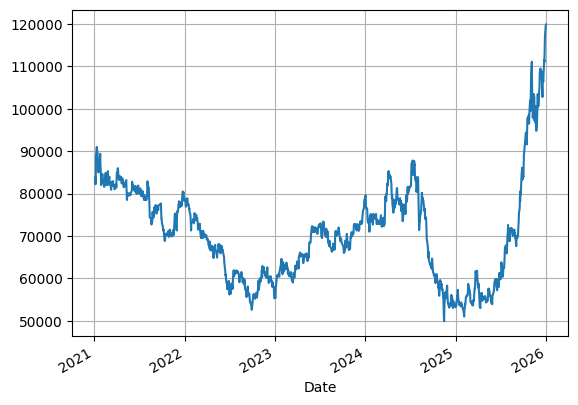

In [9]:
# 종가 Close 시각화
df['Close'].plot().grid()

# 지난날들의 데이터로 다음날 예측?

![](https://www.dropbox.com/scl/fi/ll3fbv4yi0ujlanw9necg/1.png?rlkey=zyajqonuyrsv3hgk5xyiit393&st=8l9iov4d&dl=1)

# 데이터 준비

## train, test 분리
- 70:30

In [10]:
df.head()
df[0:1]

,Open,High,Low,Volume,Close
Date,,,,,
2021-01-04,81000,84400,80200,38655276,83000


In [11]:
# train : test - 70 : 30 분리
# 시계열 데이터 (순서가 중요한 시퀀스) 는 섞으면 안된다!

SPLIT = int(len(df) * 0.7)

train_df = df[:SPLIT]
test_df = df[SPLIT:]

len(train_df), len(test_df)

(857, 368)

In [12]:
# 첫 날짜, 마지막 날짜 확인
print(train_df.index[0], '~', train_df.index[-1])
print(test_df.index[0], '~', test_df.index[-1])


2021-01-04 00:00:00 ~ 2024-06-25 00:00:00
2024-06-26 00:00:00 ~ 2025-12-30 00:00:00


#  전처리 scaling

In [13]:
# 전처리 전
df.describe()

,Open,High,Low,Volume,Close
count,1225.000000,1225.000000,1225.000000,1.225000e+03,1225.000000
mean,70791.346939,71443.673469,70108.081633,1.756622e+07,70733.877551
std,11723.182729,11851.492331,11543.861722,8.053787e+06,11716.636128
min,50200.000000,51400.000000,49900.000000,5.767902e+06,49900.000000
25%,61000.000000,61500.000000,60400.000000,1.229354e+07,60900.000000
50%,70600.000000,71000.000000,70000.000000,1.545319e+07,70500.000000
75%,78400.000000,78900.000000,77500.000000,2.082497e+07,78200.000000
max,119400.000000,121200.000000,118700.000000,9.030618e+07,119900.000000


In [14]:
# features  (맨 오른쪽 'Close' 컬럼 제외)
train_df.iloc[:, :-1]

,Open,High,Low,Volume
Date,,,,
2021-01-04,81000,84400,80200,38655276
2021-01-05,81600,83900,81600,35335669
2021-01-06,83300,84500,82100,42089013
2021-01-07,82800,84200,82700,32644642
2021-01-08,83300,90000,83000,59013307
...,...,...,...,...
2024-06-19,81100,82500,80500,24168863
2024-06-20,81500,82200,81200,20288913
2024-06-21,80700,80800,80000,17907523


In [16]:
 # target 'Close'컬럼 (Series)
train_df.iloc[:, -1]

,Close
Date,
2021-01-04,83000
2021-01-05,83900
2021-01-06,82200
2021-01-07,82900
2021-01-08,88800
...,...
2024-06-19,81200
2024-06-20,81600
2024-06-21,80000


In [28]:
# feature scaling
scaler_x = MinMaxScaler()
feature_cols = train_df.columns[:-1]

train_x_scaled = scaler_x.fit_transform(train_df[feature_cols])
test_x_scaled = scaler_x.transform(test_df[feature_cols])

In [29]:
# label scaling
# label scaling 을 별도로 하는 이유는, 우리가 test data 로 예측을 수행하면 0~1에 대응되는
# 원래의 값(label) 으로 바꾸기 위해서 scaler 의 inverse_transform 함수를 사용하기 위한 목적임
scaler_y = MinMaxScaler()
label_col = train_df.columns[-1]

train_y_scaled = scaler_y.fit_transform(train_df[[label_col]])
test_y_scaled = scaler_y.transform(test_df[[label_col]])

In [30]:
# x, y 합치기
train_df = pd.concat([
    pd.DataFrame(train_x_scaled, columns=feature_cols),
    pd.DataFrame(train_y_scaled, columns=[label_col])
], axis=1)

test_df = pd.concat([
    pd.DataFrame(test_x_scaled, columns=feature_cols),
    pd.DataFrame(test_y_scaled, columns=[label_col])
], axis=1)


In [31]:
# 전처리 결과 확인
train_df.describe()

,Open,High,Low,Volume,Close
count,857.000000,857.000000,857.000000,857.000000,857.000000
mean,0.497160,0.420167,0.497705,0.123793,0.482005
std,0.218579,0.193965,0.217554,0.086609,0.215481
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.336842,0.273148,0.336870,0.070703,0.320312
50%,0.510526,0.430556,0.511936,0.101949,0.492187
75%,0.678947,0.578704,0.671088,0.152803,0.656250
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [32]:
test_df.describe()

,Open,High,Low,Volume,Close
count,368.000000,368.000000,368.000000,368.000000,368.000000
mean,0.462057,0.396469,0.457495,0.176283,0.449488
std,0.452906,0.403566,0.448529,0.104121,0.448840
min,-0.055263,-0.050926,-0.050398,0.000952,-0.070312
25%,0.101974,0.071759,0.100796,0.102295,0.088542
50%,0.240789,0.206019,0.245358,0.156615,0.236979
75%,0.741447,0.639468,0.746021,0.222952,0.729167
max,1.765789,1.564815,1.774536,0.580289,1.752604


# 시퀀스 데이터 준비

지난날들의 시퀀스 로 다음날의 타겟값 예측!

In [34]:
def make_sequence_data(data, seq_length):
    x_seq_list = []  # List[DataFrame]
    y_seq_list = []  # List[Series]

    for i in range(len(data) - seq_length):
      x_seq_list.append(data[i:i + seq_length, :-1])  # 지난 5일(seq_length)의 시퀀스
      y_seq_list.append(data[i + seq_length, [-1]])  # 예측하고자 하는 '다음 날'의 종가(Close)

    x_seq_numpy = np.array(x_seq_list)
    y_seq_numpy = np.array(y_seq_list)

    return x_seq_numpy, y_seq_numpy


In [36]:
#  Dataset / DataLoader 만들기
# 시퀀스 길이가 5, 즉 time step 개수가 5개인 train data, test data 생성 (numpy)

x_train_data, y_train_data = make_sequence_data(train_df.to_numpy(), SEQ_LENGTH)
x_test_data, y_test_data = make_sequence_data(test_df.to_numpy(), SEQ_LENGTH)

print(x_train_data.shape, y_train_data.shape)
print(x_test_data.shape, y_test_data.shape)

# (batch, seq_len, features), (batch, target)
# (852, 5, 4) (852, 1)
# (363, 5, 4) (363, 1)

(852, 5, 4) (852, 1)
(363, 5, 4) (363, 1)


In [37]:
# TensorDataset / DataLoader 만들기
x_train_tensor = torch.FloatTensor(x_train_data).to(DEVICE)
y_train_tensor = torch.FloatTensor(y_train_data).to(DEVICE)

x_test_tensor = torch.FloatTensor(x_test_data).to(DEVICE)
y_test_tensor = torch.FloatTensor(y_test_data).to(DEVICE)

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

# shuffle=False: shuffle하면 안됨 ❌ -> 순서가 중요한 데이터이기 때문
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 모델 정의 생성

```python
torch.nn.LSTM(
    input_size,  # 한 timestep 에서 입력벡터 차원
    hidden_size,  # hidden state 의 차원
    num_layers=1,  # LSTM 을 몇개 층을 쌓을지
    bias=True,
    batch_first=False,  # 입력텐서 차원 순서
               # False : (seq_len, batch, input_size)
               # True : (batch, seq_len, input_size)
    dropout=0.0,   # dropout
    bidirectional=False,
    proj_size=0
)
```

In [39]:
class MyLSTMModel(nn.Module):

  def __init__(self, input_size, hidden_size, num_layers):
    super().__init__()
    self.num_layers = num_layers
    self.hidden_size = hidden_size

    self.lstm = nn.LSTM(
        input_size,
        hidden_size,
        num_layers,
        batch_first=True,  # 입력텐서 (batch, seq_len, input_size)
    )

    self.fc = nn.Linear(hidden_size, 1)  # 출력 1.  (회귀)


  # 입력 data: (batch, seq_len, input_size)
  def forward(self, data):
    ''' 순전파 정의 '''
    # 초기 hidden state 생성 : (num_layers, batch, hidden_size)
    #    매 forward() 할때 마다 0 으로 초기화.
    h0 = torch.zeros(self.num_layers, data.size(0), self.hidden_size).to(DEVICE)

    # 초기 cell state 생성 : (num_layers, batch, hidden_size)
    #    매 forward() 할때 마다 0 으로 초기화.
    c0 = torch.zeros(self.num_layers, data.size(0), self.hidden_size).to(DEVICE)

    # [nn.LSTM의 입출력 ]
    #    output, (h_n, c_n) = lstm(input, (h_0, c_0))

    # [입력]
    #    시퀀스 데이터 와 초기 상태(h_0, c_0)

    # [출력]
    # outputs: 모든 timestep 의 hidden state 를 모은 것
    #      shape: (batch, seq_len, hidden_size)
    #  (h_n, c_n) :  최종 hidden state, 최종 cell state
    #      shape: (num_layers * num_directions, batch, hidden_size)
    outputs, _ = self.lstm(data, (h0, c0))

    # 마지막 timestep 의 hidden state 추출
    # last_hs  (batch, hidden_size)
    last_hs = outputs[:, -1, :]

    # 회귀문제 .. 출력값 '그대로' 사용
    # ※이진분류의 경우 보통 뒤에 sigmoid
    # prediction (batch, 1)
    prediction = self.fc(last_hs)

    return prediction


![](https://www.dropbox.com/scl/fi/943vwr9n6pfid1fwlzgv2/2.png?rlkey=5tn8wpboteexvb0b9kcnmg8qb&st=0ihvufct&dl=1)

In [ ]:
# 전체적인 데이터 흐름 shape

# 입력 data
# (batch, seq, input)

# ↓ LSTM
# (batch, seq, hidden)

# ↓ 마지막 시점 선택
# (batch, hidden)

# ↓ FC
# (batch, 1)

In [40]:
model = MyLSTMModel(FEATURE_NUMS, HIDDEN_SIZE, NUM_LAYERS).to(DEVICE)

loss_function = nn.MSELoss() # 회귀문제에서 손실함수

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# train 함수

In [56]:
def model_train(dataloader, model, loss_function, optimizer):

  model.train()  # 학습모드(dropout 활성화)

  train_loss_sum = 0  # 손실함수 결과값 누적

  total_train_batch = len(dataloader)  # batch 개수

  for inputs, labels in dataloader:
    # inputs: [Open, High, Low, Volume]
    # labels: [Close]

    x_train = inputs.to(DEVICE)
    y_train = labels.to(DEVICE)

    outputs = model(x_train)  # 입력데이터에 대한 예측값 계산
    loss = loss_function(outputs, y_train)  # 예측값과 정답간의 오차계산

    # 역전파:
    optimizer.zero_grad()  # 기울기 초기화
    loss.backward()  # 역전판 기울기 계산
    optimizer.step()  # 가중치 업데이트

    train_loss_sum += loss.item()  # 매 배치마다 loss값 누적 합산


  # 평균 오차 계산
  return train_loss_sum / total_train_batch


# evaluate 함수

In [57]:
def model_evaluate(dataloader, model, loss_function, optimizer):

  model.eval()  # 평가모드(dropout 비 활성화)

  with torch.no_grad():  # 기울기 계산 비 활성화

    val_loss_sum = 0  # 손실함수 결과값 누적
    total_val_batch = len(dataloader)  # batch 개수

    for inputs, labels in dataloader:

      x_val = inputs.to(DEVICE)
      y_val = labels.to(DEVICE)

      outputs = model(x_val)
      loss = loss_function(outputs, y_val)

      val_loss_sum += loss.item()


    return val_loss_sum / total_val_batch


# 훈련

In [58]:
# colab cpu 200 epochs : 18초

from datetime import datetime

train_loss_list = []

start_time = datetime.now()

EPOCHS = 200

for epoch in range(EPOCHS):

    avg_loss = model_train(train_loader, model, loss_function, optimizer)
    train_loss_list.append(avg_loss)

    if epoch % 10 == 0:
      print('epoch:', epoch, ', train loss:', avg_loss)

end_time = datetime.now()

print('elapsed time => ', end_time-start_time)

epoch: 0 , train loss: 0.36866620568515257
epoch: 10 , train loss: 0.030475019856334426
epoch: 20 , train loss: 0.002546543494032068
epoch: 30 , train loss: 0.0019937109650210155
epoch: 40 , train loss: 0.0018473560129952898
epoch: 50 , train loss: 0.001730920144540886
epoch: 60 , train loss: 0.001639086848225033
epoch: 70 , train loss: 0.001567397427374259
epoch: 80 , train loss: 0.0015108503630049093
epoch: 90 , train loss: 0.0014644900741607903
epoch: 100 , train loss: 0.0014235729637263387
epoch: 110 , train loss: 0.0013843659084116996
epoch: 120 , train loss: 0.0013453374595819908
epoch: 130 , train loss: 0.001307173927523044
epoch: 140 , train loss: 0.0012713912573269416
epoch: 150 , train loss: 0.001239109261511002
epoch: 160 , train loss: 0.0012105756021662463
epoch: 170 , train loss: 0.0011852992787215382
epoch: 180 , train loss: 0.0011624093529589603
epoch: 190 , train loss: 0.001141209566158914
elapsed time =>  0:00:19.842532


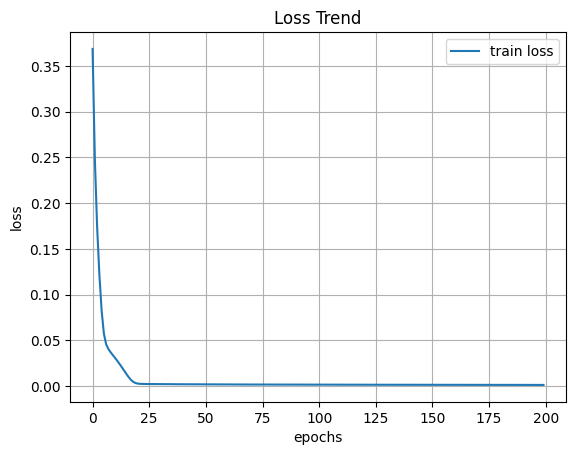

In [59]:
import matplotlib.pyplot as plt

plt.title('Loss Trend')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.grid()
plt.plot(train_loss_list, label='train loss')
plt.legend()
plt.show()

# 테스트

In [60]:
# [예측값]
test_pred_tensor = model(x_test_tensor)
test_pred_numpy = test_pred_tensor.cpu().detach().numpy()
# Autograd .  텐서가 계산 graph 에 있는 경우. 기울기값이 추적.
#   여기서 기울기값이 추적되지 않는 새로운 텐서를 리턴 -> detach()

# test_pred_numpy 의 shape?  (batch, 1)

pred_inverse = scaler_y.inverse_transform(test_pred_numpy)

# [정답]
y_test_numpy = y_test_tensor.cpu().detach().numpy()
y_test_inverse = scaler_y.inverse_transform(y_test_numpy)

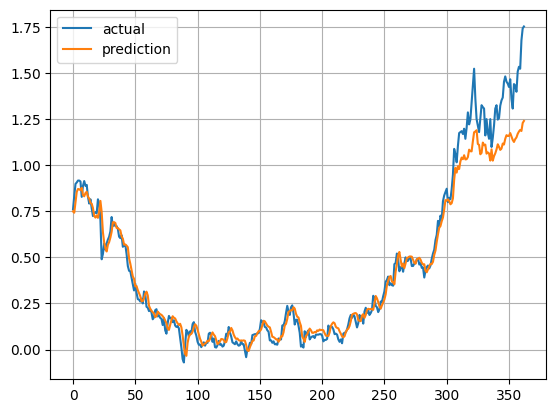

In [61]:
import matplotlib.pyplot as plt

plt.plot(y_test_inverse, label='actual')
plt.plot(pred_inverse, label='prediction')
plt.grid()
plt.legend()

plt.show()